### 🚀 For an interactive experience, head over to our [demo platform](https://var.vision/demo) and dive right in! 🌟

In [ ]:
################## 1. Download checkpoints and build models
import os
import os.path as osp
import torch, torchvision
import random
import numpy as np
import PIL.Image as PImage, PIL.ImageDraw as PImageDraw
setattr(torch.nn.Linear, 'reset_parameters', lambda self: None)     # disable default parameter init for faster speed
setattr(torch.nn.LayerNorm, 'reset_parameters', lambda self: None)  # disable default parameter init for faster speed
from models import VQVAE, build_vae_var

MODEL_DEPTH = 16    # TODO: =====> please specify MODEL_DEPTH <=====
assert MODEL_DEPTH in {16, 20, 24, 30}


# download checkpoint
hf_home = 'https://huggingface.co/FoundationVision/var/resolve/main'
vae_ckpt, var_ckpt = 'vae_ch160v4096z32.pth', f'var_d{MODEL_DEPTH}.pth'
if not osp.exists(vae_ckpt): os.system(f'wget {hf_home}/{vae_ckpt}')
if not osp.exists(var_ckpt): os.system(f'wget {hf_home}/{var_ckpt}')

# build vae, var
patch_nums = (1, 2, 3, 4, 5, 6, 8, 10, 13, 16)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if 'vae' not in globals() or 'var' not in globals():
    vae, var = build_vae_var(
        V=4096, Cvae=32, ch=160, share_quant_resi=4,    # hard-coded VQVAE hyperparameters
        device=device, patch_nums=patch_nums,
        num_classes=1000, depth=MODEL_DEPTH, shared_aln=False,
    )

# load checkpoints
vae.load_state_dict(torch.load(vae_ckpt, map_location='cpu'), strict=True)
var.load_state_dict(torch.load(var_ckpt, map_location='cpu'), strict=True)
vae.eval(), var.eval()
for p in vae.parameters(): p.requires_grad_(False)
for p in var.parameters(): p.requires_grad_(False)
print(f'prepare finished.')

/home/yuchenliu/miniconda3/envs/var/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
--2025-07-11 17:12:54--  https://huggingface.co/FoundationVision/var/resolve/main/vae_ch160v4096z32.pth
Resolving huggingface.co (huggingface.co)... 18.164.174.118, 18.164.174.23, 18.164.174.17, ...
Connecting to huggingface.co (huggingface.co)|18.164.174.118|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs-us-1.hf.co/repos/27/33/2733ebd65833f8330005ce942c9195c84a3d385ac604d32ebe5d6d9a79385456/7c3ec27ae28a3f87055e83211ea8cc8558bd1985d7b51742d074fb4c2fcf186c?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27vae_ch160v4096z32.pth%3B+filename%3D%22vae_ch160v4096z32.pth%22%3B&Expires=1752282774&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkV


[constructor]  ==== flash_if_available=True (0/16), fused_if_available=True (fusing_add_ln=0/16, fusing_mlp=0/16) ==== 
    [VAR config ] embed_dim=1024, num_heads=16, depth=16, mlp_ratio=4.0
    [drop ratios ] drop_rate=0.0, attn_drop_rate=0.0, drop_path_rate=0.0666667 (tensor([0.0000, 0.0044, 0.0089, 0.0133, 0.0178, 0.0222, 0.0267, 0.0311, 0.0356,
        0.0400, 0.0444, 0.0489, 0.0533, 0.0578, 0.0622, 0.0667]))

[init_weights] VAR with init_std=0.0180422
prepare finished.


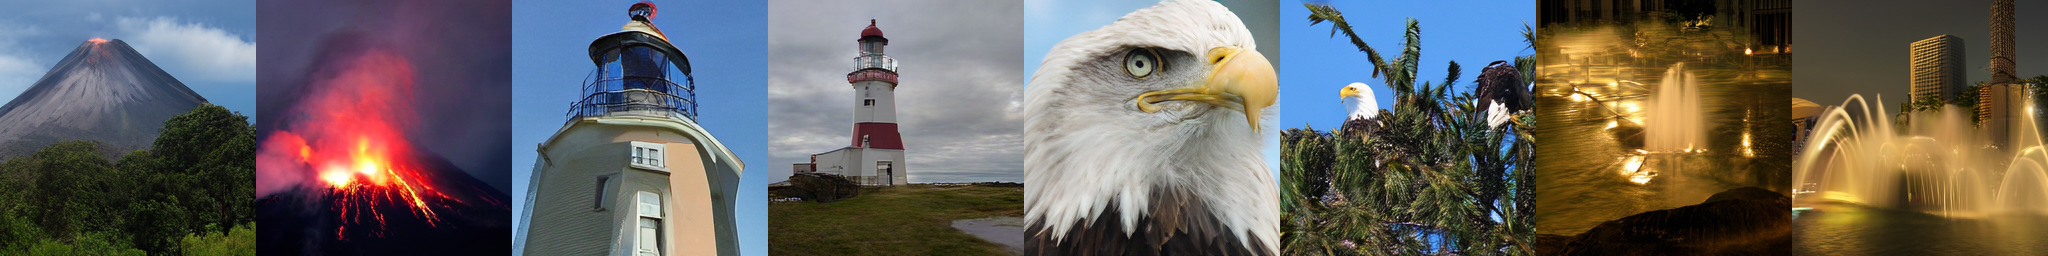

In [2]:
############################# 2. Sample with classifier-free guidance

# set args
seed = 0 #@param {type:"number"}
torch.manual_seed(seed)
num_sampling_steps = 250 #@param {type:"slider", min:0, max:1000, step:1}
cfg = 4 #@param {type:"slider", min:1, max:10, step:0.1}
class_labels = (980, 980, 437, 437, 22, 22, 562, 562)  #@param {type:"raw"}
more_smooth = False # True for more smooth output

# seed
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# run faster
tf32 = True
torch.backends.cudnn.allow_tf32 = bool(tf32)
torch.backends.cuda.matmul.allow_tf32 = bool(tf32)
torch.set_float32_matmul_precision('high' if tf32 else 'highest')

# sample
B = len(class_labels)
label_B: torch.LongTensor = torch.tensor(class_labels, device=device)
with torch.inference_mode():
    with torch.autocast('cuda', enabled=True, dtype=torch.float16, cache_enabled=True):    # using bfloat16 can be faster
        recon_B3HW = var.autoregressive_infer_cfg(B=B, label_B=label_B, cfg=cfg, top_k=900, top_p=0.95, g_seed=seed, more_smooth=more_smooth)

chw = torchvision.utils.make_grid(recon_B3HW, nrow=8, padding=0, pad_value=1.0)
chw = chw.permute(1, 2, 0).mul_(255).cpu().numpy()
chw = PImage.fromarray(chw.astype(np.uint8))
chw.show()


Using device: cuda

[constructor]  ==== flash_if_available=True (0/8), fused_if_available=True (fusing_add_ln=0/8, fusing_mlp=0/8) ==== 
    [VAR config ] embed_dim=1024, num_heads=8, depth=8, mlp_ratio=4.0
    [drop ratios ] drop_rate=0.0, attn_drop_rate=0.0, drop_path_rate=0.1 (tensor([0.0000, 0.0143, 0.0286, 0.0429, 0.0571, 0.0714, 0.0857, 0.1000]))

[init_weights] VARGrayscale with init_std=0.0180422
Models built successfully
VQVAE: vocab_size=128, z_channels=16
VAR: patch_nums=(1, 2, 4, 8), depth=16
🔄 Loading VQVAE from: /home/yuchenliu/VAR/local_output/vqvae_checkpoints_v128_z16_c64_b1_lpips/vqvae_epoch_190.pth
✅ Loaded VQVAE from training checkpoint
🔄 Loading VAR from: /home/yuchenliu/VAR/local_output/var_custom_v128_z16_c64_lpips_d8_h8/ar-ckpt-best.pth
✅ VAR loaded successfully
🎯 Models ready for sampling!

🎨 Generating 8 grayscale MRI samples...
✅ Generated images shape: torch.Size([8, 1, 128, 128])


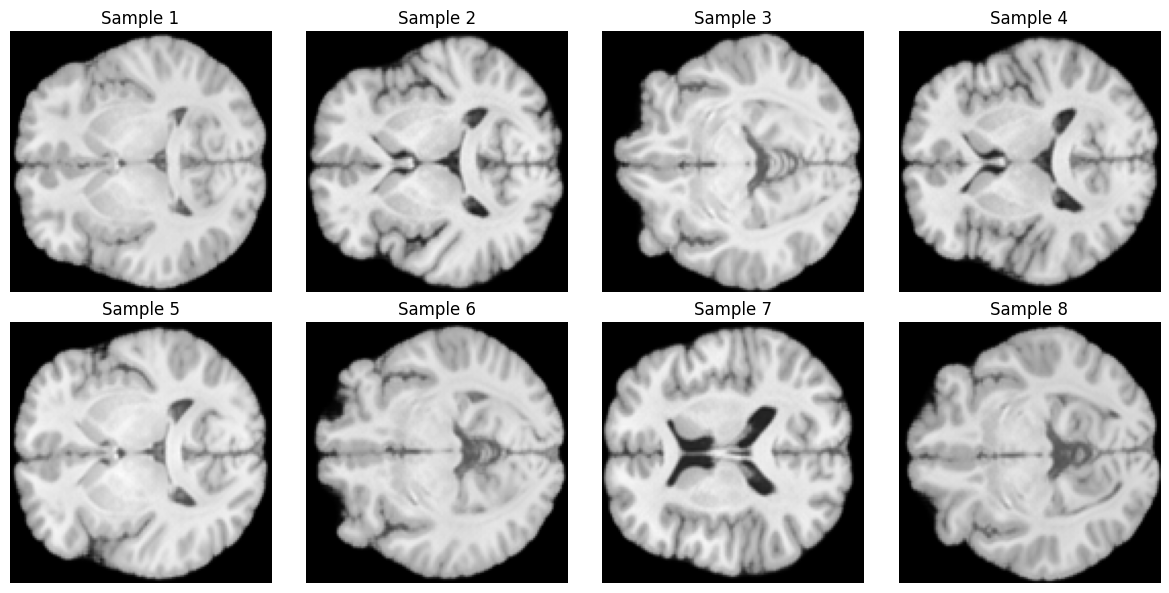

💾 Saved 8 individual samples to 'generated_samples/' directory
💾 Saved grid image as 'generated_mri_samples.png'

🎉 Sampling completed successfully!


In [3]:
import os
import os.path as osp
import torch, torchvision
import random
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image as PImage, PIL.ImageDraw as PImageDraw

# Disable default parameter init for faster speed
setattr(torch.nn.Linear, 'reset_parameters', lambda self: None)
setattr(torch.nn.LayerNorm, 'reset_parameters', lambda self: None)

from models import build_vae_var_grayscale

# Configuration matching your training setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Build models with the exact same parameters as your training
vae, var = build_vae_var_grayscale(
    V=128,           # vocab_size to match your VQVAE
    Cvae=16,         # z_channels to match your VQVAE  
    ch=64,           # ch to match your VQVAE
    share_quant_resi=4,
    device=device, 
    patch_nums=(1, 2, 4, 8),  # Match your training patch_nums
    depth=8,        # VAR depth from your training
    num_heads=8,
    shared_aln=False,
    # Optional: add these if needed for exact match
    # flash_if_available=True, 
    # fused_if_available=True,
    # init_adaln=0.5, 
    # init_adaln_gamma=1e-5, 
    # init_head=0.02, 
    # init_std=-1,
)

print(f"Models built successfully")
print(f"VQVAE: vocab_size={vae.vocab_size}, z_channels={vae.Cvae}")
print(f"VAR: patch_nums={(1, 2, 4, 8)}, depth=16")

# Load your trained checkpoints
vqvae_ckpt_path = '/home/yuchenliu/VAR/local_output/vqvae_checkpoints_v128_z16_c64_b1_lpips/vqvae_epoch_190.pth'
var_ckpt_path = '/home/yuchenliu/VAR/local_output/var_custom_v128_z16_c64_b1_lpips/ar-ckpt-best.pth'
var_ckpt_path = '/home/yuchenliu/VAR/local_output/var_custom_v128_z16_c64_lpips_d8_h8/ar-ckpt-best.pth'

# Load VQVAE checkpoint
print(f"🔄 Loading VQVAE from: {vqvae_ckpt_path}")
if not os.path.exists(vqvae_ckpt_path):
    raise FileNotFoundError(f"VQVAE checkpoint not found: {vqvae_ckpt_path}")

vqvae_checkpoint = torch.load(vqvae_ckpt_path, map_location='cpu')
# Handle different checkpoint formats (direct state_dict vs training checkpoint)
if 'model_state_dict' in vqvae_checkpoint:
    vae_state_dict = vqvae_checkpoint['model_state_dict']
    print(f"✅ Loaded VQVAE from training checkpoint")
else:
    vae_state_dict = vqvae_checkpoint
    print(f"✅ Loaded VQVAE from direct state dict")

vae.load_state_dict(vae_state_dict, strict=True)

# Load VAR checkpoint
print(f"🔄 Loading VAR from: {var_ckpt_path}")
if not os.path.exists(var_ckpt_path):
    raise FileNotFoundError(f"VAR checkpoint not found: {var_ckpt_path}")

var_checkpoint = torch.load(var_ckpt_path, map_location='cpu')
# Extract VAR state dict from trainer checkpoint
var_state_dict = var_checkpoint['trainer']['var_wo_ddp']
var.load_state_dict(var_state_dict, strict=True)
print(f"✅ VAR loaded successfully")

# Set models to evaluation mode
vae.eval(), var.eval()

# Disable gradients for inference
for p in vae.parameters(): 
    p.requires_grad_(False)
for p in var.parameters(): 
    p.requires_grad_(False)

print(f"🎯 Models ready for sampling!")

# Generate grayscale MRI samples
seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

# Sampling parameters
B = 8  # Number of samples
print(f"\n🎨 Generating {B} grayscale MRI samples...")

with torch.inference_mode():
    with torch.autocast('cuda', enabled=True, dtype=torch.float16, cache_enabled=True):
        # Unconditional generation for grayscale images
        generated_images = var.autoregressive_infer_unconditional(
            B=B, 
            g_seed=seed, 
            top_k=50, 
            top_p=0.95, 
            more_smooth=False
        )

print(f"✅ Generated images shape: {generated_images.shape}")  # Should be [B, 1, H, W]

# Visualize results with matplotlib
plt.figure(figsize=(12, 6))
for i in range(B):
    plt.subplot(2, 4, i+1)
    # generated_images should be in range [0, 1] for grayscale
    img = generated_images[i, 0].cpu().numpy()
    plt.imshow(img, cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
    plt.title(f'Sample {i+1}')

plt.tight_layout()
plt.savefig('generated_mri_samples_grid.png', dpi=150, bbox_inches='tight')
plt.show()

# Save individual samples
os.makedirs('generated_samples', exist_ok=True)
for i in range(B):
    # Convert to PIL Image and save
    img_array = generated_images[i, 0].cpu().numpy()
    # Ensure values are in [0, 1] range
    img_array = np.clip(img_array, 0, 1)
    # Convert to 0-255 range for PIL
    img_pil = PImage.fromarray((img_array * 255).astype(np.uint8), mode='L')
    img_pil.save(f'generated_samples/sample_{i+1:02d}.png')

print(f"💾 Saved {B} individual samples to 'generated_samples/' directory")

# Also create a grid image similar to your original code
if generated_images.dim() == 4 and generated_images.shape[1] == 1:
    # Convert grayscale to RGB for torchvision.utils.make_grid
    generated_rgb = generated_images.repeat(1, 3, 1, 1)  # [B, 1, H, W] -> [B, 3, H, W]
    
    chw = torchvision.utils.make_grid(generated_rgb, nrow=4, padding=2, pad_value=1.0)
    chw = chw.permute(1, 2, 0).mul_(255).cpu().numpy()
    chw = PImage.fromarray(chw.astype(np.uint8))
    chw.save('generated_mri_samples.png')
    print(f"💾 Saved grid image as 'generated_mri_samples.png'")

print(f"\n🎉 Sampling completed successfully!")

In [ ]:
import os
import os.path as osp
import torch, torchvision
import random
import numpy as np
import PIL.Image as PImage, PIL.ImageDraw as PImageDraw
setattr(torch.nn.Linear, 'reset_parameters', lambda self: None)     # disable default parameter init for faster speed
setattr(torch.nn.LayerNorm, 'reset_parameters', lambda self: None)  # disable default parameter init for faster speed
from models import VQVAE, build_vae_var, build_vae_var_unconditional

# Load your trained model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
vae, var = build_vae_var_unconditional(
    V=4096, Cvae=32, ch=160, share_quant_resi=4,
    device=device, patch_nums=(1, 2, 3, 4, 5, 6, 8, 10, 13, 16),
    depth=16, shared_aln=False,
)

# Load your trained checkpoints
vae.load_state_dict(torch.load('vae_ch160v4096z32.pth', map_location='cpu'), strict=True)
var.load_state_dict(torch.load('local_output/ar-ckpt-best.pth', map_location='cpu')['trainer']['var_wo_ddp'], strict=True)
vae.eval(), var.eval()

# Generate unconditional samples
seed = 42
torch.manual_seed(seed)
B = 8  # Number of samples

with torch.inference_mode():
    with torch.autocast('cuda', enabled=True, dtype=torch.float16, cache_enabled=True):
        # Unconditional generation
        recon_B3HW = var.autoregressive_infer_unconditional(
            B=B, g_seed=seed, top_k=900, top_p=0.95, more_smooth=False
        )

# Visualize results
chw = torchvision.utils.make_grid(recon_B3HW, nrow=4, padding=0, pad_value=1.0)
chw = chw.permute(1, 2, 0).mul_(255).cpu().numpy()
chw = PImage.fromarray(chw.astype(np.uint8))
chw.show()
chw.save('generated_mri_samples.png')

In [ ]:
import os
import os.path as osp
import torch, torchvision
import random
import numpy as np
import PIL.Image as PImage, PIL.ImageDraw as PImageDraw
setattr(torch.nn.Linear, 'reset_parameters', lambda self: None)     # disable default parameter init for faster speed
setattr(torch.nn.LayerNorm, 'reset_parameters', lambda self: None)  # disable default parameter init for faster speed
from models import build_vae_var_grayscale

# Load model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
vae, var = build_vae_var_grayscale(device=device)

# Load checkpoints (you'll need to train these first)
vae.load_state_dict(torch.load('vae_grayscale.pth', map_location='cpu'), strict=True)
var.load_state_dict(torch.load('var_grayscale.pth', map_location='cpu'), strict=True)
vae.eval(), var.eval()

# Generate grayscale samples
B = 8
with torch.inference_mode():
    generated_images = var.autoregressive_infer_unconditional(
        B=B, g_seed=42, top_k=900, top_p=0.95, more_smooth=False
    )

# Visualize (generated_images shape: B, 1, H, W)
for i in range(B):
    plt.subplot(2, 4, i+1)
    plt.imshow(generated_images[i, 0].cpu().numpy(), cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()